# Food Delivery Order Analytics
**Author:** Uday Garg  
**Dataset:** 12,000 food delivery orders across 12 Indian cities (Oct 2025 – Sep 2026)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy  
**Objective:** Identify key drivers of delivery time and restaurant performance to support 
data-driven operational decisions for a food delivery platform.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
%matplotlib inline

# Food Delivery Order Analytics — EDA & Statistical Insights
**Business Objective:** Analyze 12,000+ food delivery orders across 12 Indian cities to uncover 
what drives delivery time and restaurant performance, and deliver data-driven recommendations 
for platform operations.

**Key Questions:**
1. Does traffic level significantly affect delivery time?
2. Does weather (rain/fog) cause meaningful delays?
3. Is there a correlation between distance and delivery time?
4. Which cities/cuisines have the highest ratings and order volume?
5. Does online ordering / table booking relate to restaurant rating?

In [2]:
df = pd.read_csv("C:/Users/Uday/Downloads/food_delivery_analytics_data.csv")
df.shape

(12120, 19)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12120 entries, 0 to 12119
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   order_id           12120 non-null  object 
 1   order_date         12120 non-null  object 
 2   restaurant_id      12120 non-null  object 
 3   restaurant_name    12120 non-null  object 
 4   city               12012 non-null  object 
 5   location           11896 non-null  object 
 6   cuisines           12120 non-null  object 
 7   rest_type          12120 non-null  object 
 8   cost_for_two       12120 non-null  object 
 9   online_order       12120 non-null  object 
 10  book_table         12120 non-null  object 
 11  rating             11267 non-null  object 
 12  votes              12120 non-null  int64  
 13  distance_km        12120 non-null  float64
 14  traffic_level      12120 non-null  object 
 15  weather_condition  12120 non-null  object 
 16  delivery_time_min  121

In [4]:
df.head(10)

,order_id,order_date,restaurant_id,restaurant_name,city,location,cuisines,rest_type,cost_for_two,online_order,book_table,rating,votes,distance_km,traffic_level,weather_condition,delivery_time_min,payment_method,discount_applied
0,ORD109105,21/04/2026 15:49,R1316,Spice Corner,Mumbai,Andheri,"Rolls, Fast Food, Italian",Cloud Kitchen,1500,Yes,No,3.4/5,73,6.8,Medium,Windy,30.4,UPI,No
1,ORD108870,25/02/2026 09:25,R1219,Biryani Dhaba,Ghaziabad,Indirapuram,"Chinese, Mexican, Cafe",Quick Bites,700,No,Yes,-,176,0.8,Low,Clear,12.6,Cash on Delivery,No
2,ORD100135,26/05/2026 14:17,R1112,Classic Nest,Jaipur,Malviya Nagar,"Burger, chinese",Quick Bites,600,Yes,Yes,3.7,620,2.6,Low,Clear,17.2,UPI,No
3,ORD110426,15/10/2025 18:39,R1261,Tandoori Treat,Bangalore,Jayanagar,"Mughlai, Pizza",Lounge,700,No,No,4.2,105,1.8,High,Rainy,32.8,UPI,No
4,ORD108644,23/06/2026 08:14,R1205,Urban Junction,Hyderabad,Jubilee Hills,South indian,Cloud Kitchen,300,No,No,3.9/5,132,0.9,Medium,Windy,20.7,UPI,Yes
5,ORD104503,28/03/2026 15:35,R1215,Punjabi Dhaba,Hyderabad,Jubilee Hills,"NORTH INDIAN, Healthy Food, Biryani",Delivery Only,350,Yes,No,4.6,38,3.0,Jam,Cloudy,40.4,Net Banking,Yes
6,ORD100631,05/04/2026 19:49,R1296,Spice Point,Delhi,Rajouri Garden,"Cafe, Beverages, Rolls",Casual Dining,400,no,No,2.5/5,194,2.2,Jam,Cloudy,39.4,UPI,No
7,ORD111130,04/12/2025 15:40,R1442,Metro Kitchen,Mumbai,Malad,"Desserts, Bakery, Street Food",Quick Bites,500,yes,Yes,4.1/5,39,1.9,Jam,Clear,41.0,Wallet,No
8,ORD102385,03/04/2026 16:05,R1202,The Nest,Delhi,Karol Bagh,"Mughlai, Thai",Lounge,700,yes,Yes,4.7,275,1.4,Jam,Rainy,42.0,Card,Yes
9,ORD104803,06/07/2026 22:11,R1397,Spice Bistro,Faridabad,Old Faridabad,"Burger, Mexican, Pizza",Casual Dining,350,No,No,4.7,140,5.3,Low,Clear,30.9,Cash on Delivery,Yes


In [5]:
df.isnull().sum()

order_id               0
order_date             0
restaurant_id          0
restaurant_name        0
city                 108
location             224
cuisines               0
rest_type              0
cost_for_two           0
online_order           0
book_table             0
rating               853
votes                  0
distance_km            0
traffic_level          0
weather_condition      0
delivery_time_min      0
payment_method         0
discount_applied       0
dtype: int64

In [6]:
df.describe(include='all')

,order_id,order_date,restaurant_id,restaurant_name,city,location,cuisines,rest_type,cost_for_two,online_order,book_table,rating,votes,distance_km,traffic_level,weather_condition,delivery_time_min,payment_method,discount_applied
count,12120,12120,12120,12120,12012,11896,12120,12120,12120,12120,12120,11267,12120.000000,12120.000000,12120,12120,12120.000000,12120,12120
unique,12000,11767,450,248,12,53,298,11,19,4,2,52,NaN,NaN,4,5,NaN,5,2
top,ORD109822,02/06/2026 18:45,R1331,Metro Table,Gurugram,Vaishali Nagar,Continental,Cloud Kitchen,250,Yes,No,-,NaN,NaN,Medium,Clear,NaN,UPI,No
freq,2,3,43,166,1180,537,373,1229,1076,4388,8535,371,NaN,NaN,4853,5135,NaN,4016,8048
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,287.270215,2.985173,NaN,NaN,28.515503,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,302.327384,2.082316,NaN,NaN,9.802550,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1360.000000,0.000000,NaN,NaN,10.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.000000,1.400000,NaN,NaN,21.300000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,203.000000,2.500000,NaN,NaN,27.600000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,407.000000,4.000000,NaN,NaN,35.100000,NaN,NaN


In [7]:
df.duplicated().sum()

np.int64(120)

In [8]:
df = df.drop_duplicates()
df.shape

(12000, 19)

In [9]:
#STAGE - 2 (CLEANING)

In [10]:
df['rating'].unique()[:20]

array(['3.4/5', '-', '3.7', '4.2', '3.9/5', '4.6', '2.5/5', '4.1/5',
       '4.7', nan, '3.1/5', '3.0', '3.8/5', '3.5/5', '3.7/5', 'NEW',
       '4.5', '3.3', '2.7', '4.1'], dtype=object)

In [11]:
df['rating'] = df['rating'].astype(str).str.replace('/5', '', regex=False)
df['rating'] = df['rating'].replace(['NEW', '-', 'nan'], np.nan)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating'].describe()

count    10437.000000
mean         3.753425
std          0.668827
min          2.500000
25%          3.200000
50%          3.800000
75%          4.300000
max          4.900000
Name: rating, dtype: float64

In [12]:
df['cost_for_two'].unique()[:15]

array(['1500', '700', '600', '300', '350', '400', '500', '800', '2000',
       '250', '200', '1,500', '1000', '150', '900'], dtype=object)

In [13]:
df['cost_for_two'] = df['cost_for_two'].astype(str).str.replace(',', '', regex=False)
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')
df['cost_for_two'].describe()

count    12000.000000
mean       730.045833
std        518.617428
min        150.000000
25%        300.000000
50%        600.000000
75%       1000.000000
max       2000.000000
Name: cost_for_two, dtype: float64

In [14]:
(df['votes'] < 0).sum()

np.int64(196)

In [15]:
df['votes'] = df['votes'].abs()
df['votes'].describe()

count    12000.000000
mean       296.372917
std        292.375378
min          0.000000
25%         87.000000
50%        208.000000
75%        411.000000
max       3146.000000
Name: votes, dtype: float64

In [16]:
df['order_date'] = pd.to_datetime(df['order_date'], format="%d/%m/%Y %H:%M")
df['order_date'].describe()

count                            12000
mean     2026-03-21 13:57:09.125000192
min                2025-10-01 08:11:00
25%                2025-12-24 13:14:45
50%                2026-03-21 15:45:30
75%                2026-06-15 23:14:45
max                2026-09-10 23:07:00
Name: order_date, dtype: object

In [17]:
df['city'] = df['city'].fillna('Unknown')
df['location'] = df['location'].fillna('Unknown')
df[['city','location']].isnull().sum()

city        0
location    0
dtype: int64

In [18]:
df['online_order'].unique()

array(['Yes', 'No', 'no', 'yes'], dtype=object)

In [19]:
df['online_order'] = df['online_order'].str.strip().str.title()
df['book_table'] = df['book_table'].str.strip().str.title()
df['discount_applied'] = df['discount_applied'].str.strip().str.title()
df['cuisines'] = df['cuisines'].str.strip().str.title()
df['city'] = df['city'].str.strip().str.title()
df['location'] = df['location'].str.strip().str.title()

df['online_order'].unique()

array(['Yes', 'No'], dtype=object)

In [20]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 0 to 12119
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           12000 non-null  object        
 1   order_date         12000 non-null  datetime64[ns]
 2   restaurant_id      12000 non-null  object        
 3   restaurant_name    12000 non-null  object        
 4   city               12000 non-null  object        
 5   location           12000 non-null  object        
 6   cuisines           12000 non-null  object        
 7   rest_type          12000 non-null  object        
 8   cost_for_two       12000 non-null  int64         
 9   online_order       12000 non-null  object        
 10  book_table         12000 non-null  object        
 11  rating             10437 non-null  float64       
 12  votes              12000 non-null  int64         
 13  distance_km        12000 non-null  float64       
 14  traffic_lev

In [21]:
#Stage 3: Feature Engineering

In [22]:
df['order_hour'] = df['order_date'].dt.hour
df['order_day_name'] = df['order_date'].dt.day_name()
df['order_month'] = df['order_date'].dt.month_name()
df['is_weekend'] = df['order_day_name'].isin(['Saturday', 'Sunday'])

df[['order_date','order_hour','order_day_name','order_month','is_weekend']].head()

,order_date,order_hour,order_day_name,order_month,is_weekend
0,2026-04-21 15:49:00,15,Tuesday,April,False
1,2026-02-25 09:25:00,9,Wednesday,February,False
2,2026-05-26 14:17:00,14,Tuesday,May,False
3,2025-10-15 18:39:00,18,Wednesday,October,False
4,2026-06-23 08:14:00,8,Tuesday,June,False


In [23]:
def cost_bucket(cost):
    if cost <= 300:
        return "Budget"
    elif cost <= 700:
        return "Mid-Range"
    elif cost <= 1200:
        return "Premium"
    else:
        return "Luxury"

df['cost_category'] = df['cost_for_two'].apply(cost_bucket)
df['cost_category'].value_counts()

cost_category
Mid-Range    3801
Budget       3381
Premium      3039
Luxury       1779
Name: count, dtype: int64

In [24]:
def rating_tier(r):
    if pd.isna(r):
        return "Unrated"
    elif r >= 4.0:
        return "High"
    elif r >= 3.0:
        return "Medium"
    else:
        return "Low"

df['rating_tier'] = df['rating'].apply(rating_tier)
df['rating_tier'].value_counts()

rating_tier
Medium     4442
High       4381
Low        1614
Unrated    1563
Name: count, dtype: int64

In [25]:
def meal_slot(hour):
    if 6 <= hour < 11:
        return "Breakfast"
    elif 11 <= hour < 16:
        return "Lunch"
    elif 16 <= hour < 20:
        return "Evening Snacks"
    else:
        return "Dinner"

df['meal_slot'] = df['order_hour'].apply(meal_slot)
df['meal_slot'].value_counts()

meal_slot
Lunch             3664
Dinner            3111
Evening Snacks    3007
Breakfast         2218
Name: count, dtype: int64

In [26]:
#Stage 4: Univariate EDA (distribution of one variable at a time)

In [27]:
import seaborn as sns
print(sns.__version__)

0.13.2


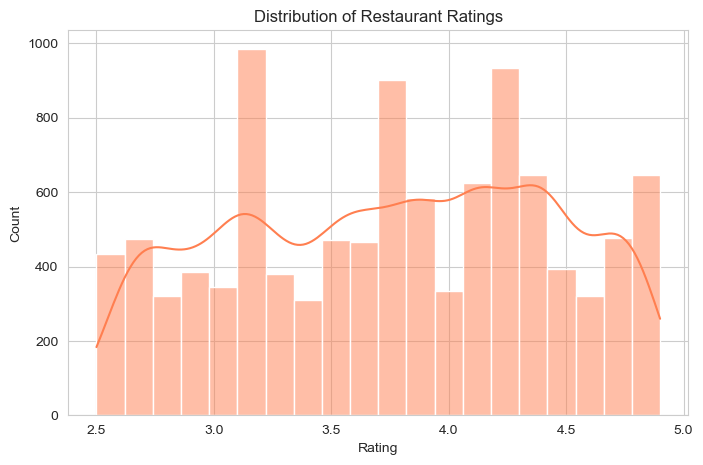

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['rating'].dropna(), bins=20, kde=True, color='coral')
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

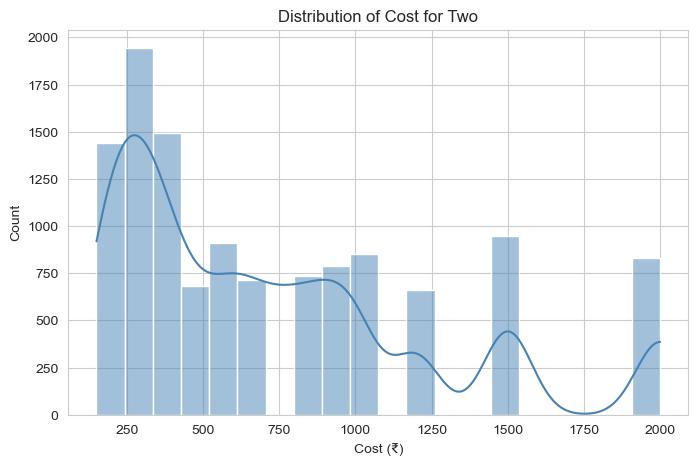

In [29]:
#distribution of cost_for_two:
plt.figure(figsize=(8,5))
sns.histplot(df['cost_for_two'], bins=20, kde=True, color='steelblue')
plt.title("Distribution of Cost for Two")
plt.xlabel("Cost (₹)")
plt.show()

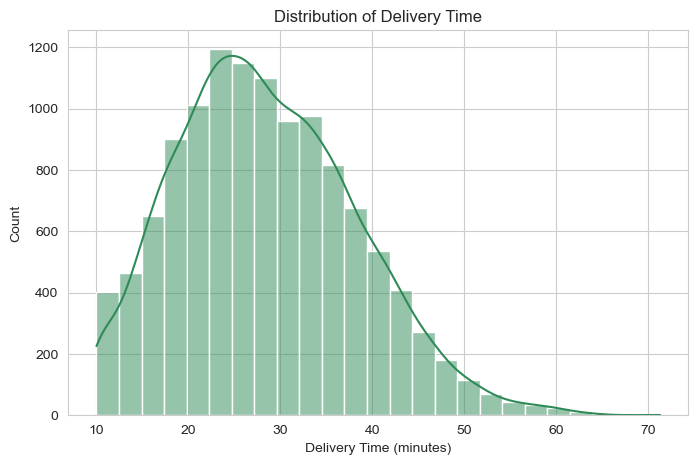

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df['delivery_time_min'], bins=25, kde=True, color='seagreen')
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.show()

C:\Users\Uday\AppData\Local\Temp\ipykernel_9296\2367348669.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cost_category', data=df, order=['Budget','Mid-Range','Premium','Luxury'], ax=ax[0], palette='Blues')
C:\Users\Uday\AppData\Local\Temp\ipykernel_9296\2367348669.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='meal_slot', data=df, order=['Breakfast','Lunch','Evening Snacks','Dinner'], ax=ax[1], palette='Oranges')
C:\Users\Uday\AppData\Local\Temp\ipykernel_9296\2367348669.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countp

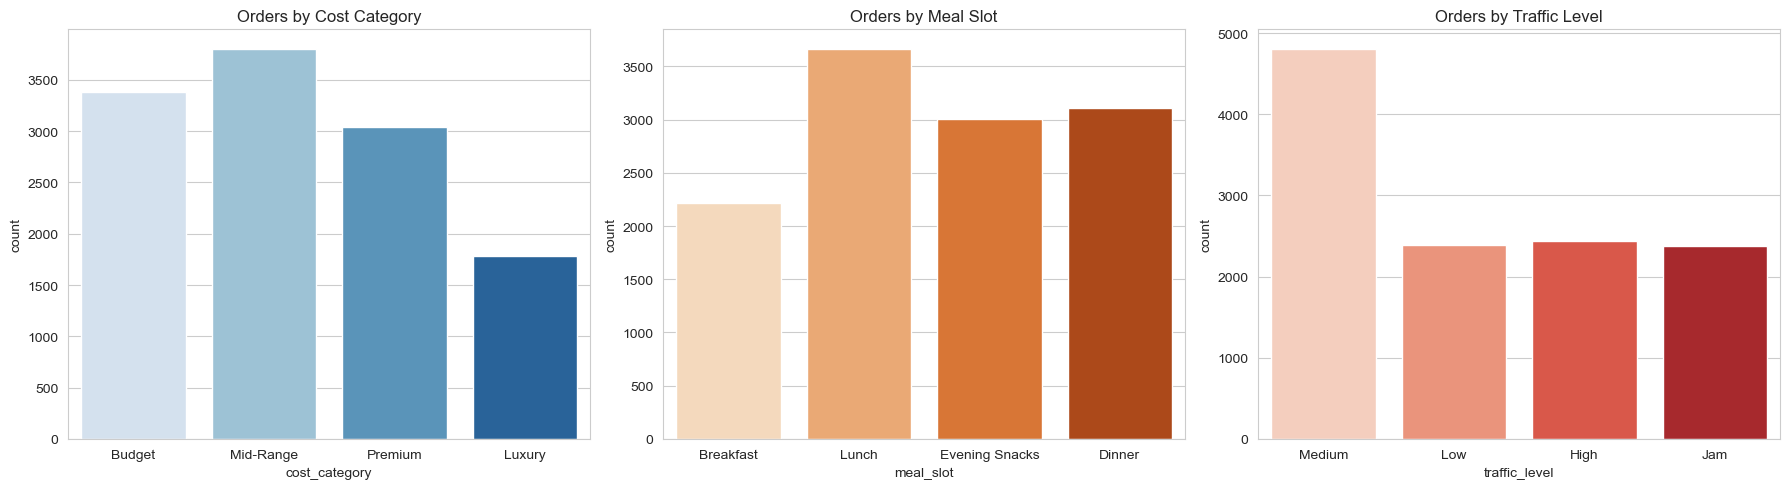

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

sns.countplot(x='cost_category', data=df, order=['Budget','Mid-Range','Premium','Luxury'], ax=ax[0], palette='Blues')
ax[0].set_title("Orders by Cost Category")

sns.countplot(x='meal_slot', data=df, order=['Breakfast','Lunch','Evening Snacks','Dinner'], ax=ax[1], palette='Oranges')
ax[1].set_title("Orders by Meal Slot")

sns.countplot(x='traffic_level', data=df, ax=ax[2], palette='Reds')
ax[2].set_title("Orders by Traffic Level")

plt.tight_layout()
plt.show()

In [32]:
#Stage 5: Bivariate EDA (relationship between two variables)

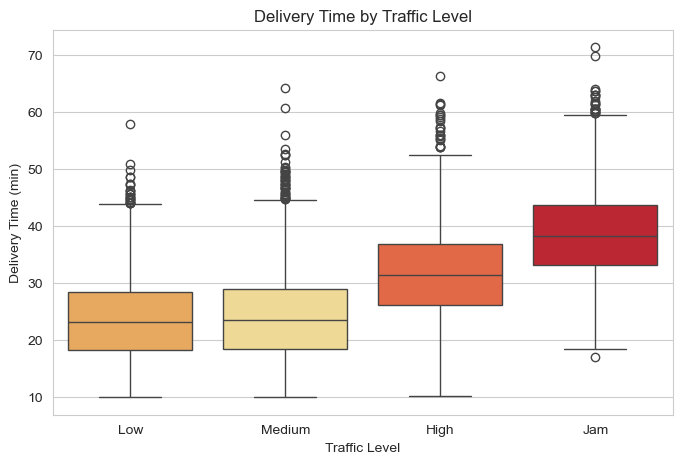

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x='traffic_level', y='delivery_time_min', hue='traffic_level', data=df,
            order=['Low','Medium','High','Jam'], palette='YlOrRd', legend=False)
plt.title("Delivery Time by Traffic Level")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time (min)")
plt.show()

C:\Users\Uday\AppData\Local\Temp\ipykernel_9296\474827782.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather_condition', y='delivery_time_min', data=df, palette='Blues')


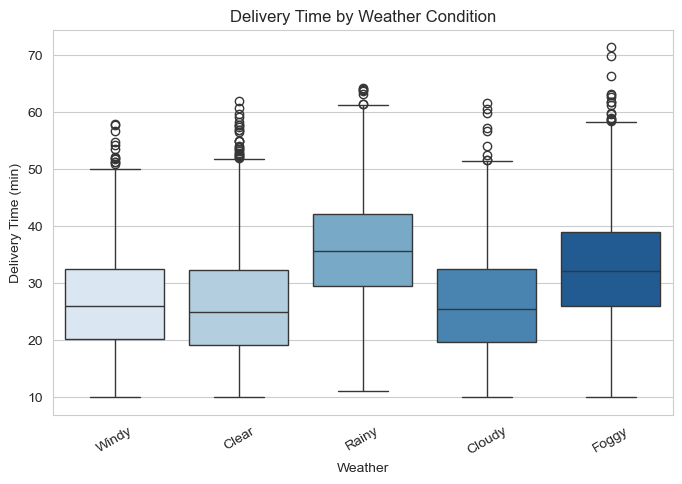

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x='weather_condition', y='delivery_time_min', data=df, palette='Blues')
plt.title("Delivery Time by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Delivery Time (min)")
plt.xticks(rotation=30)
plt.show()

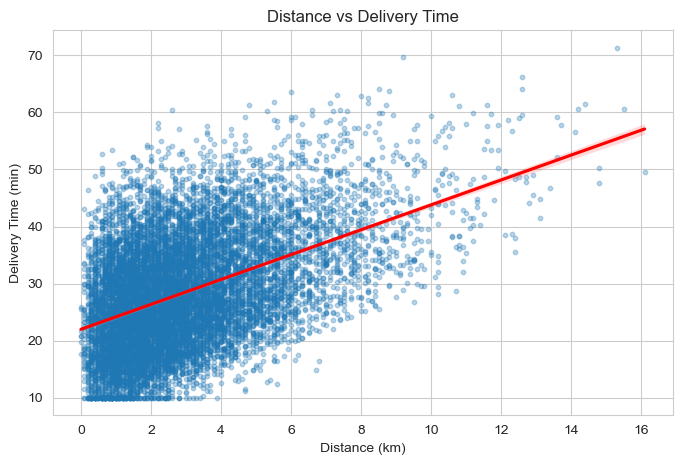

In [35]:
plt.figure(figsize=(8,5))
sns.regplot(x='distance_km', y='delivery_time_min', data=df,
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
plt.title("Distance vs Delivery Time")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.show()

C:\Users\Uday\AppData\Local\Temp\ipykernel_9296\2316880177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cost_category', y='rating', data=df,


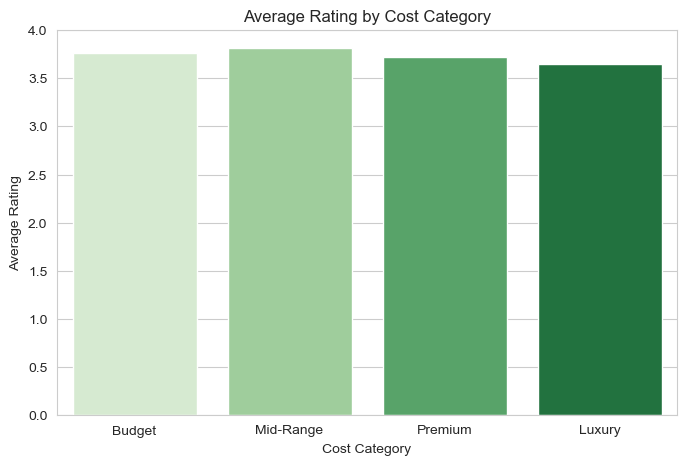

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(x='cost_category', y='rating', data=df,
            order=['Budget','Mid-Range','Premium','Luxury'], palette='Greens', errorbar=None)
plt.title("Average Rating by Cost Category")
plt.xlabel("Cost Category")
plt.ylabel("Average Rating")
plt.show()

C:\Users\Uday\AppData\Local\Temp\ipykernel_9296\2227978880.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')


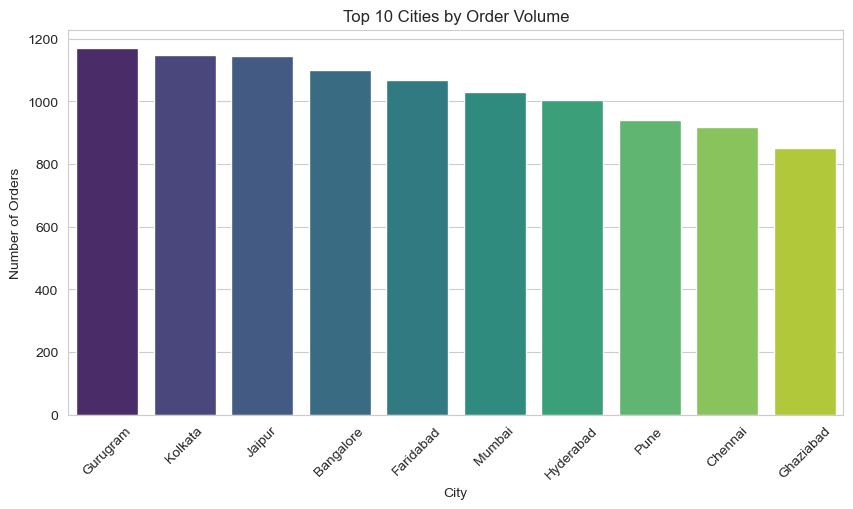

In [37]:
plt.figure(figsize=(10,5))
top_cities = df['city'].value_counts().head(10)
sns.barplot(x=top_cities.index, y=top_cities.values, palette='viridis')
plt.title("Top 10 Cities by Order Volume")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

In [38]:
#Stage 6: Statistical Testing (turning visuals into proof)

In [39]:
#Does rain significantly increase delivery time? (Independent t-test)
clear_time = df[df['weather_condition'] == 'Clear']['delivery_time_min']
rainy_time = df[df['weather_condition'] == 'Rainy']['delivery_time_min']

t_stat, p_value = stats.ttest_ind(rainy_time, clear_time, equal_var=False)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")
print(f"Rainy mean: {rainy_time.mean():.2f} min | Clear mean: {clear_time.mean():.2f} min")

if p_value < 0.05:
    print("Result: Statistically significant difference (reject H0)")
else:
    print("Result: No significant difference (fail to reject H0)")

T-statistic: 40.484
P-value: 0.00000
Rainy mean: 36.16 min | Clear mean: 25.98 min
Result: Statistically significant difference (reject H0)


In [40]:
#Does traffic level affect delivery time across ALL groups? (ANOVA)
low = df[df['traffic_level']=='Low']['delivery_time_min']
med = df[df['traffic_level']=='Medium']['delivery_time_min']
high = df[df['traffic_level']=='High']['delivery_time_min']
jam = df[df['traffic_level']=='Jam']['delivery_time_min']

f_stat, p_value = stats.f_oneway(low, med, high, jam)
print(f"F-statistic: {f_stat:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Traffic level significantly affects delivery time (reject H0)")
else:
    print("Result: No significant effect (fail to reject H0)")

F-statistic: 2379.473
P-value: 0.00000
Result: Traffic level significantly affects delivery time (reject H0)


In [41]:
# Correlation Test: Distance vs Delivery Time (Pearson correlation)
corr, p_value = stats.pearsonr(df['distance_km'], df['delivery_time_min'])
print(f"Correlation coefficient: {corr:.3f}")
print(f"P-value: {p_value:.5f}")

Correlation coefficient: 0.463
P-value: 0.00000


In [42]:
#Chi-Square Test: Is online ordering associated with table booking? (categorical vs categorical)
contingency = pd.crosstab(df['online_order'], df['book_table'])
print(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi2 statistic: {chi2:.3f}")
print(f"P-value: {p_value:.5f}")

if p_value < 0.05:
    print("Result: Significant association between online ordering and table booking")
else:
    print("Result: No significant association")

book_table      No   Yes
online_order            
No            3499  1332
Yes           4964  2205

Chi2 statistic: 13.936
P-value: 0.00019
Result: Significant association between online ordering and table booking


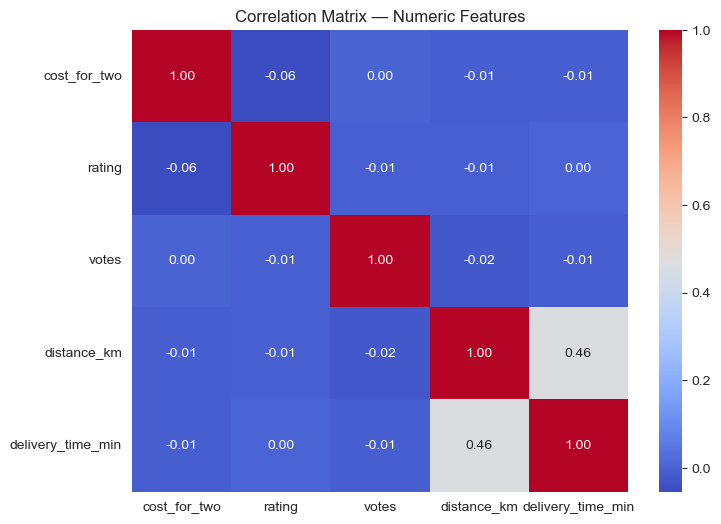

In [43]:
#full correlation matrix + heatmap (all numeric columns at once):
plt.figure(figsize=(8,6))
numeric_cols = df[['cost_for_two','rating','votes','distance_km','delivery_time_min']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix — Numeric Features")
plt.show()

#Stage 7: Business Insights & Recommendations

## Key Insights & Recommendations

### 1. Traffic is the strongest delay driver
ANOVA confirms delivery time differs significantly across traffic levels (F = 2379.47, p < 0.001).
This is the largest effect size observed in the dataset.
**Recommendation:** Build dynamic ETAs using real-time traffic data instead of a flat estimate — 
traffic level alone explains more variation in delivery time than any other factor tested.

### 2. Weather causes measurable delays
Rainy-day deliveries average 36.16 minutes vs 25.98 minutes on clear days — a 10.18 minute 
(39%) increase (t = 40.48, p < 0.001).
**Recommendation:** Auto-apply a delivery time buffer during rain-flagged orders to manage 
customer expectations and reduce complaint volume.

### 3. Distance and delivery time are moderately correlated
Pearson r = 0.463 (p < 0.001) — a moderate positive correlation. Distance matters, but the 
strength of the traffic/weather effects (above) shows delivery time is not distance alone.
**Recommendation:** Segment delivery partner assignment by distance tier, but weight traffic 
conditions more heavily than raw distance when setting SLAs.

### 4. Online ordering and table booking are significantly associated
Chi-square = 13.94, p = 0.00019. Restaurants offering online ordering show a higher proportion 
of table booking availability (30.7% vs 27.6% for non-online-order restaurants).
**Recommendation:** Restaurants adopting online ordering are more likely to be "full-service" — 
bundle onboarding for both features together rather than promoting them separately.

### 5. Gurugram leads order volume, followed by Kolkata and Jaipur
Gurugram recorded ~1,170 orders — the highest of all 12 cities — with Kolkata and Jaipur close behind.
The correlation matrix also confirms cost, rating, and votes are largely independent of each other 
(all |r| < 0.06), while distance and delivery time remain the only strongly linked numeric pair (r = 0.46).

**Recommendation:** 
Prioritize delivery partner capacity and restaurant onboarding in Gurugram, Kolkata, and Jaipur — 
the top 3 cities by demand.

In [44]:
#(cost category summary table):
summary = df.groupby('cost_category', observed=True).agg(
    avg_rating=('rating','mean'),
    avg_delivery_time=('delivery_time_min','mean'),
    total_orders=('order_id','count')
).round(2)
summary

,avg_rating,avg_delivery_time,total_orders
cost_category,,,
Budget,3.77,28.61,3381
Luxury,3.65,28.31,1779
Mid-Range,3.81,28.67,3801
Premium,3.73,28.33,3039
